In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain.tools import tool
from typing import Dict, Any
from tavily import TavilyClient

tavily_client = TavilyClient()

@tool
def web_search(query: str) -> Dict[str, Any]:

    """Search the web for information"""

    return tavily_client.search(query)

In [3]:
system_prompt = """

You are a personal chef. The user will give you a list of ingredients they have left over in their house.

Using the web search tool, search the web for recipes that can be made with the ingredients they have.

Return recipe suggestions and eventually the recipe instructions to the user, if requested.

"""

In [4]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model="google_genai:gemini-3.1-flash-lite",
    tools=[web_search],
    system_prompt=system_prompt,
    checkpointer=InMemorySaver()
)

In [5]:
from langchain.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}

response = agent.invoke(
    {"messages": [HumanMessage(content="I have some leftover chicken and rice. What can I make?")]},
    config
)

print(response['messages'][-1].content[0]['text'])

Chicken and rice is a classic combination with endless possibilities. Because your ingredients are already cooked, you can have a delicious meal ready in minutes.

Here are my top three recommendations for using up your leftovers:

### 1. Chicken Fried Rice (The Quickest Option)
This is the ultimate "clean out the fridge" meal. It’s fast, flavorful, and uses high heat to crisp up the rice.
*   **What you need:** Your chicken and rice, soy sauce, a little oil (sesame oil is great if you have it), garlic, and any frozen veggies (peas/carrots/corn) or eggs you have on hand.
*   **Why it works:** Cold, leftover rice actually fries better than fresh rice because it’s drier and won't get mushy.

### 2. Cheesy Chicken and Rice Casserole (The Comfort Option)
If you want something warm and cozy, this is the way to go.
*   **What you need:** Your chicken and rice, a can of cream-based soup (like cream of mushroom or chicken), some shredded cheese, and perhaps some frozen broccoli or herbs.
*   *

In [8]:
question = HumanMessage(content="I realised I also have beef cubes, ginger, and potatoes. What dish should I make now if I want a dish that combines all these additional ingredients with my previous leftovers?")

response = agent.invoke(
    {"messages": [question]},
    config,
)

print(response['messages'][-1].content[0]['text'])

Since you have chicken, rice, beef cubes, ginger, and potatoes, the best way to combine all of them is to make a **"Savory Ginger-Beef & Chicken Potato Stew"** served over your rice.

By using the beef cubes to create a rich, savory broth and the ginger to add a bright, aromatic punch, you transform your leftovers into a completely new, hearty meal.

### **Savory Ginger-Beef & Chicken Potato Stew**

This dish uses the potatoes to thicken the sauce and the ginger to balance the savory depth of the beef cubes.

**Prep time:** 10 mins | **Cook time:** 15–20 mins

#### **Ingredients:**
*   Leftover chicken (shredded or chopped)
*   Leftover rice
*   Potatoes (peeled and diced into ½-inch cubes)
*   Beef cubes (1 or 2, depending on how much liquid you use)
*   Ginger (about 1 inch, minced or finely grated)
*   *Pantry staples needed:* Oil, water, salt/pepper, and soy sauce (if you have it).

---

#### **Instructions:**

1.  **Sauté the Aromatics:** Heat a little oil in a pot over medium hea

In [9]:
from pprint import pprint
pprint(response)

{'messages': [HumanMessage(content='I have some leftover chicken and rice. What can I make?', additional_kwargs={}, response_metadata={}, id='4fbb3d2c-6cee-467d-85e6-989ad5930992'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "recipes using leftover chicken and rice"}'}, '__gemini_function_call_thought_signatures__': {'call_163870': 'EnMKcQFpFH0TjKnd5EBZDumRU0OGxRUoRDpAFbfy8vYexDq3B3SXRlVLufN+Vw08A9+/WuWhpLKYJlLrkOoq2NEEM7dEwVAdCXeiRz8HDyUFWUG3PCSm1kX6K7so9CjmTDrcUtVKenOaEpwAnBuHLimwi1eu'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0f56e-07a9-7a30-a699-03396a40e98c-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'recipes using leftover chicken and rice'}, 'id': 'call_163870', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 119, 'output_tokens': 21, 'total_tokens

Learning Points:
- By specifying the checkpointer and also including the config for the agent to use the same thread, notice that a follow up question that involves the leftovers (without specifying what they are) identifies the leftovers correctly based on the previous message.
- This example demonstrates state/memory.

# Using LangSmith Studio
- LangSmith is a interface to interact with your agent and visualize the execution flow
- While notebooks are good for tutorials and debugging, the agent should be converted to an actual Python file for the studio
- In the terminal, run `langgraph dev` and LangSmith studio will run locally and pop up in a browser window
  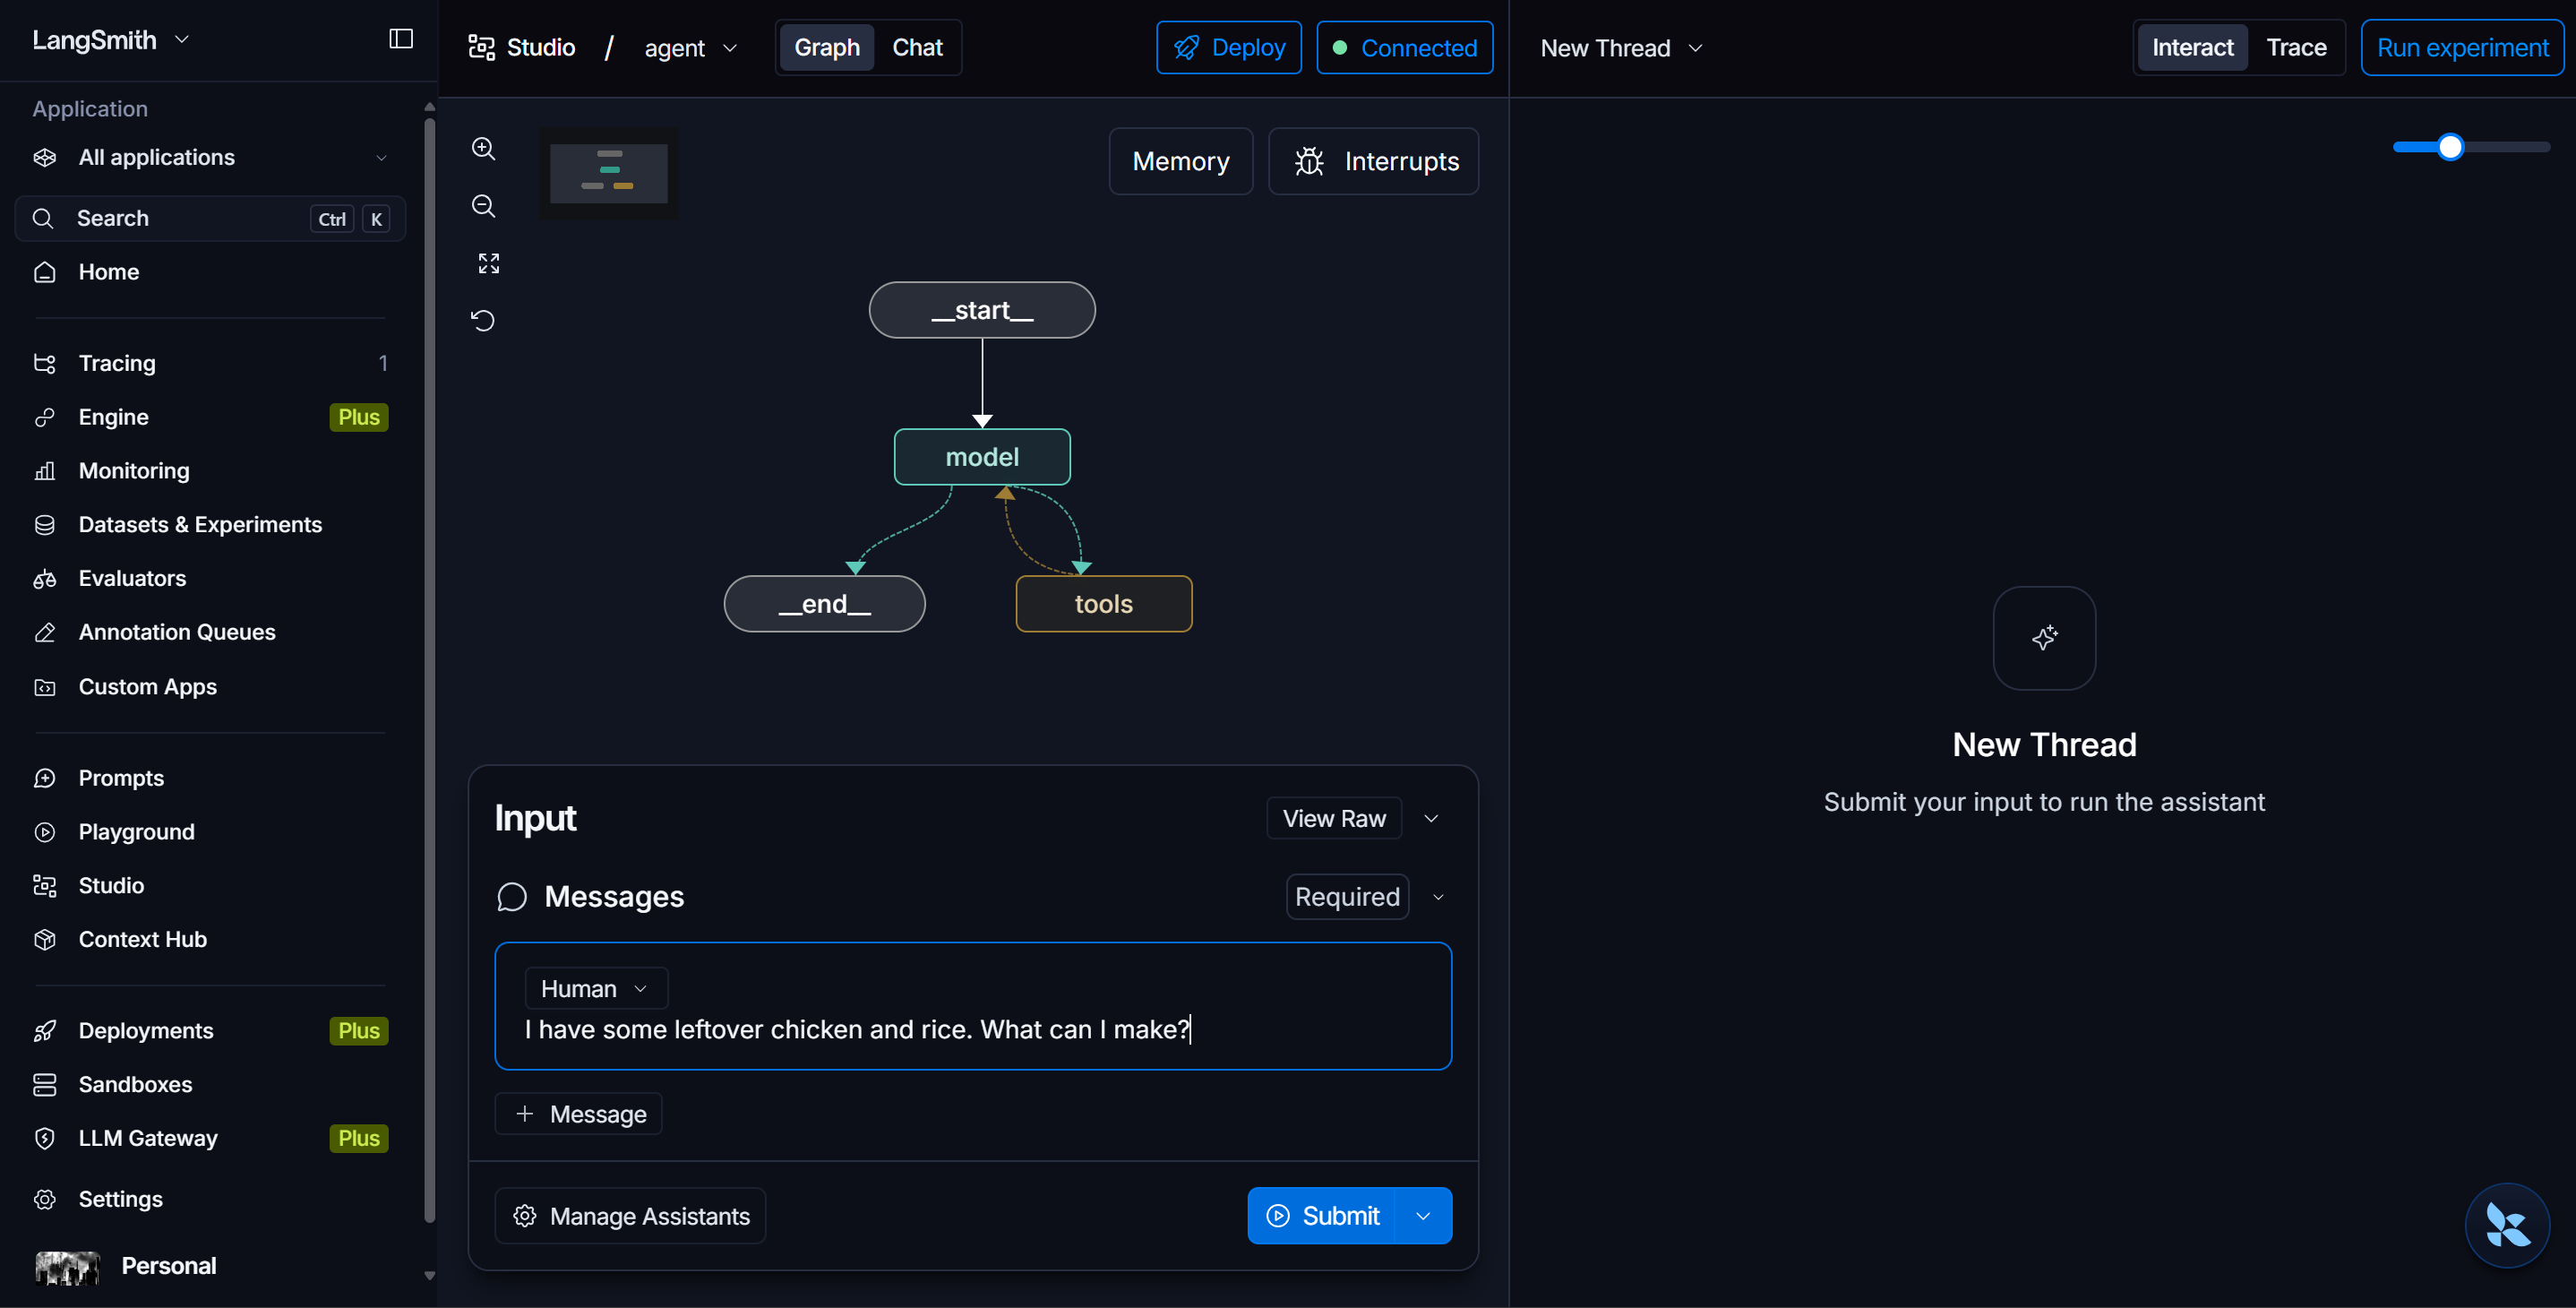
- Prompt it and you can view the execution flow
  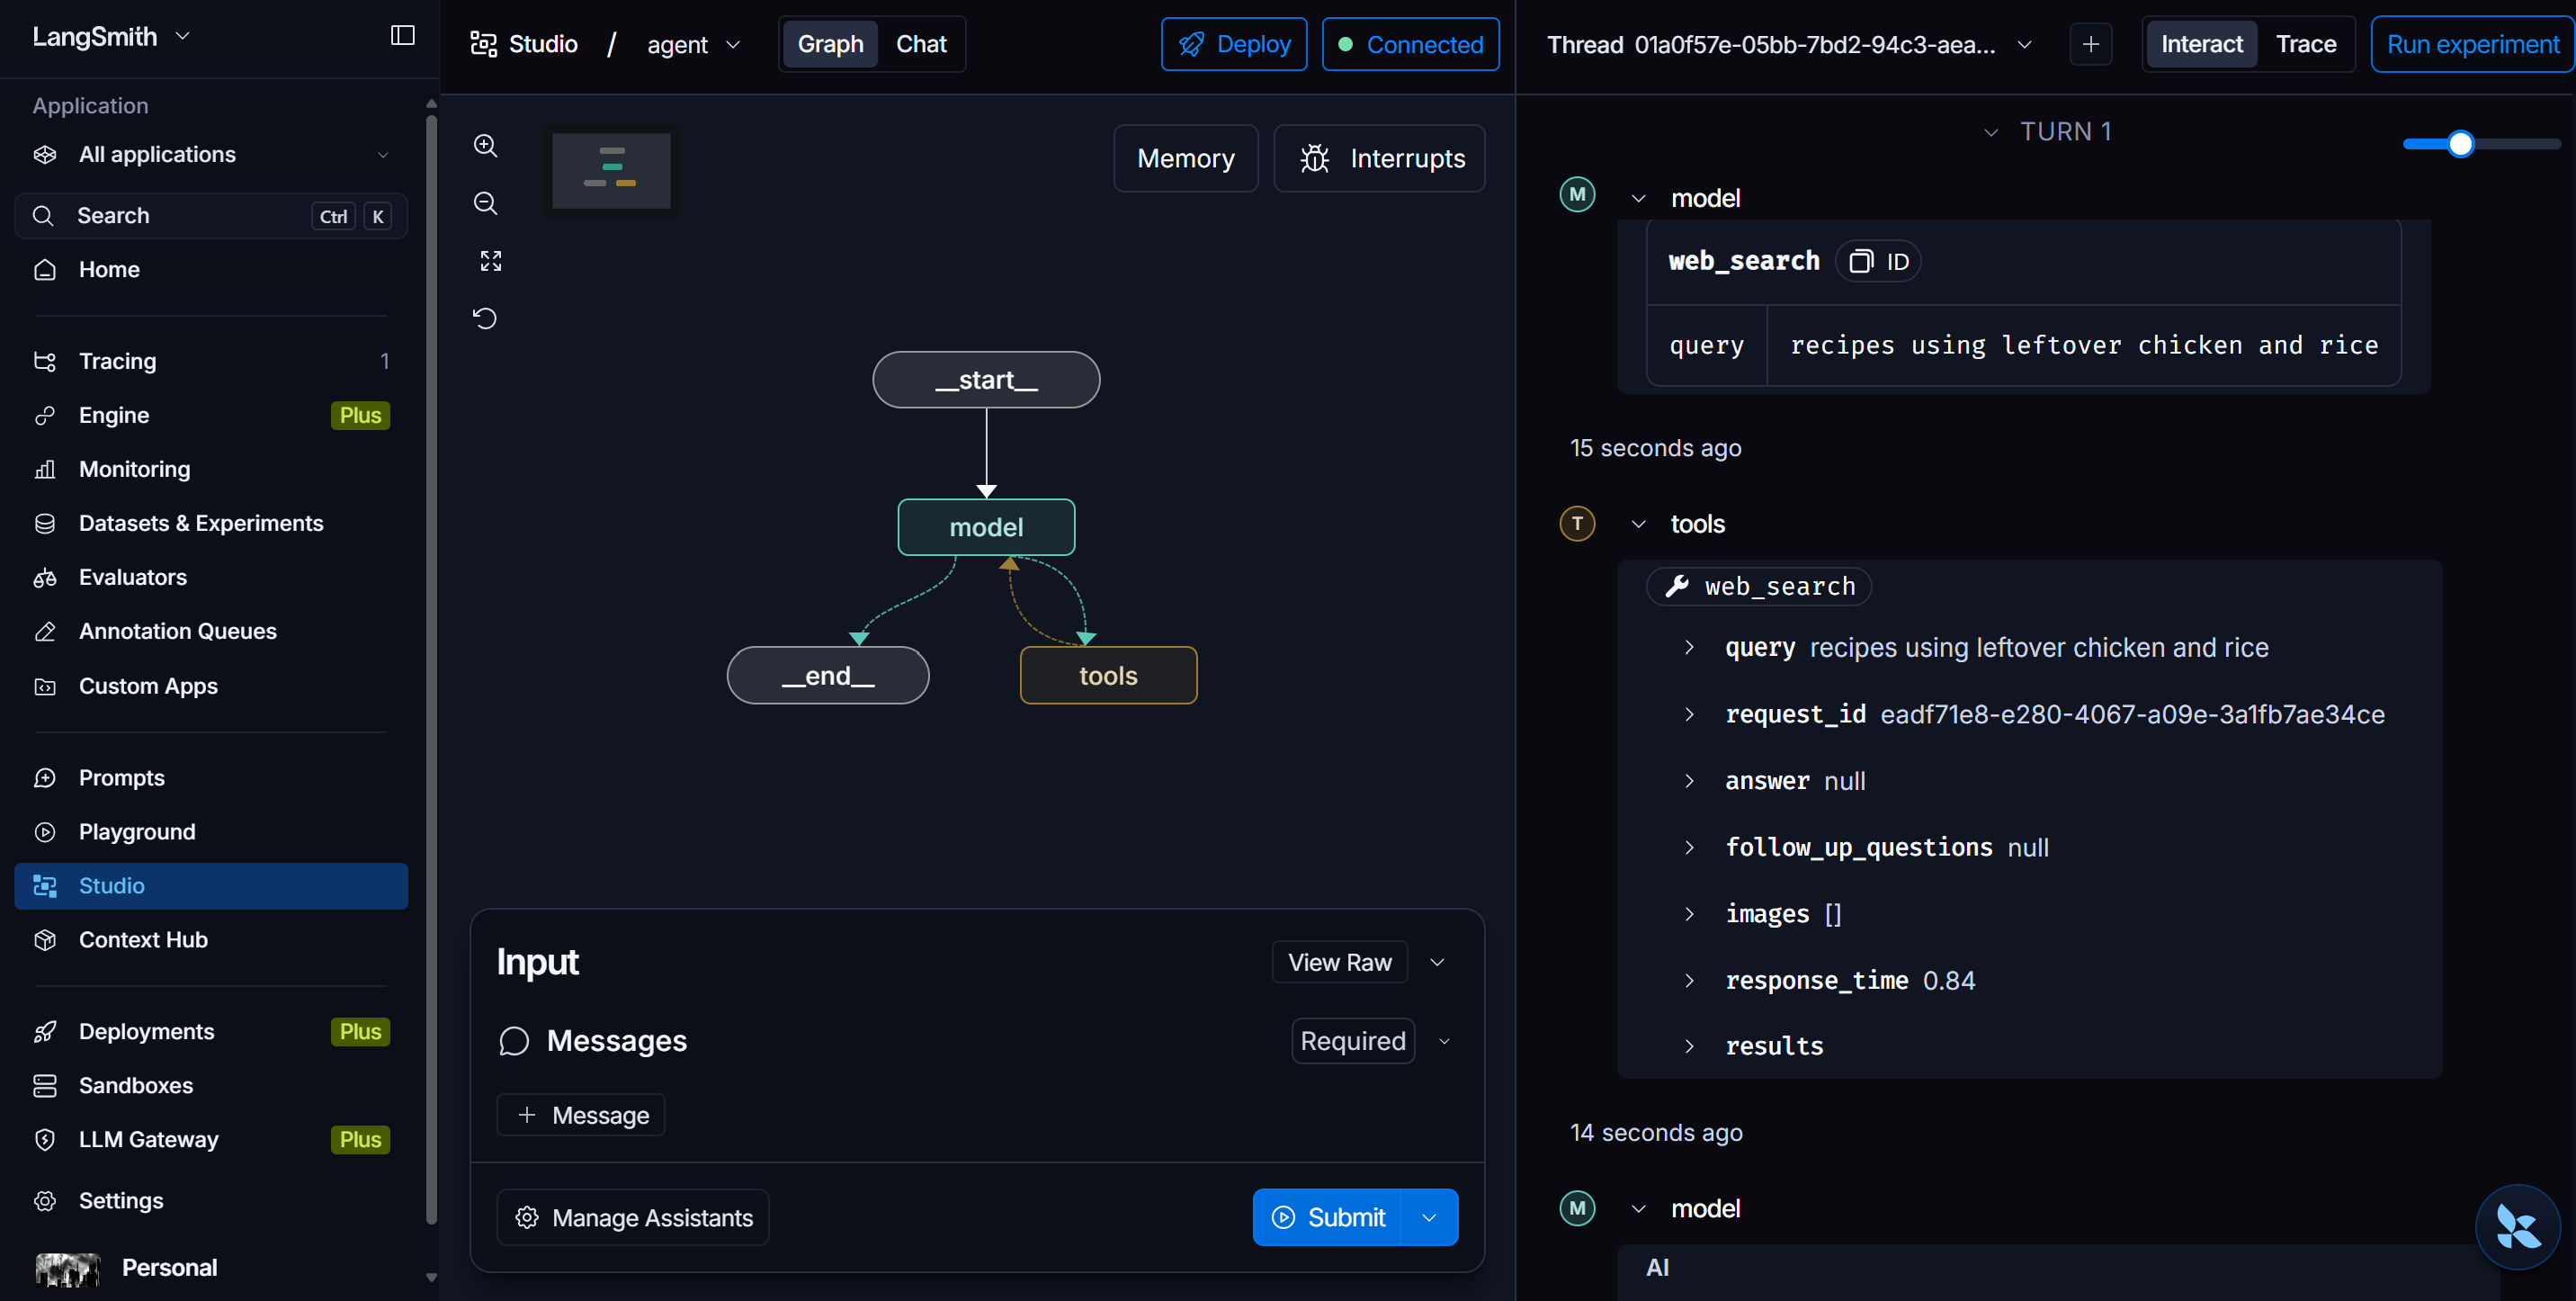